# 23_01 상태 변화 추적 

In [20]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 데이터 불러오기와 단일 설비 센서 그리기

### 목표
데이터를 불러와 구조를 확인하고 엔진 한 대를 골라 센서를 시간순으로 그리기

### 단계
- 파일을 불러와 크기와 엔진 목록 확인
- 2번 엔진만 골라 회차 순으로 정렬
- 센서 하나를 시간순 선 그래프로 그리기

### 예상 결과
전체 1036행·엔진 5대, 2번 엔진 287행; 센서 곡선이 그려짐

   설비번호  시퀀스  컨베이어전류   회전A전류   회전B전류  펌프A전류  펌프B전류
0     2    1     0.0  0.0496  0.7037    0.0    0.0
1     2    2     0.0  0.0496  0.7037    0.0    0.0
2     2    3     0.0  0.0496  0.7037    0.0    0.0


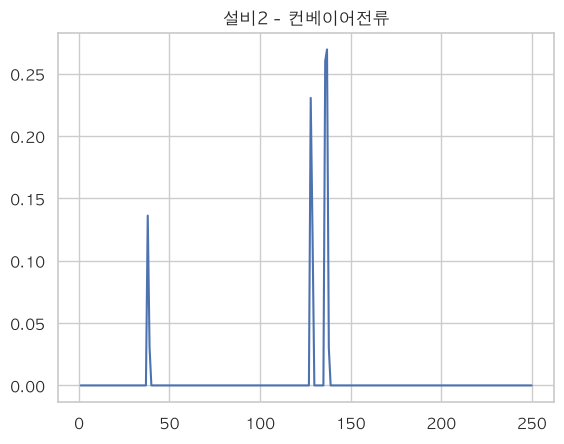

In [21]:
# 실습 1 코드

df = pd.read_csv("data/23_전기Panel.csv", encoding="UTF-8")

unit2 = df[df["설비번호"] == 2].copy().sort_values("시퀀스").reset_index(drop=True)

print(unit2.head(3))

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"])
plt.title("설비2 - 컨베이어전류")
plt.show()

## 실습 2. 단일 센서 이동평균 추적

## 목표
창 크기 10 이동평균을 구해 원본 위에 겹쳐 추세를 읽기
### 단계
- 센서에 창 크기 10 이동평균을 새 열로 담기
- 원본을 옅게, 이동평균을 진하게 겹쳐 그리기
- 이동평균선이 추세를 드러냄을 확인
### 예상 결과
들쭉날쭉한 원본 위로 매끈한 이동평균 추세선

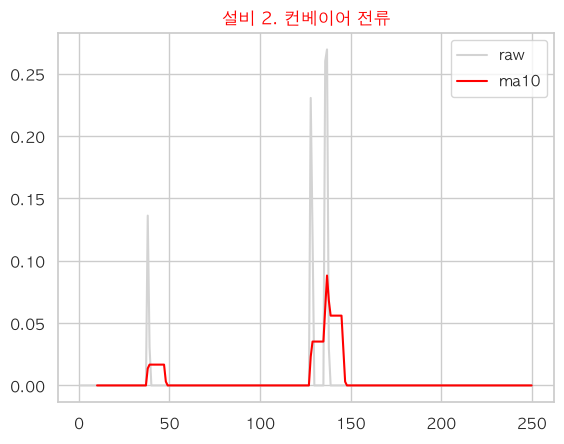

In [22]:
# 실습 2 코드

unit2["ma10"] = unit2["컨베이어전류"].rolling(window=10).mean()

unit2.tail(10)

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color = "lightgray", label="raw" )
plt.plot(unit2["시퀀스"], unit2["ma10"], color="red", label="ma10") # 조금 더 평탄화됨

plt.legend()
plt.title("설비 2. 컨베이어 전류", color = "red")
plt.show()


## 실습 3. 창 크기 3종 비교

### 목표
창 크기를 5·10·30으로 바꿔 매끈함과 반응성의 맞교환을 비교
### 단계
- 세 가지 창 크기로 이동평균을 각각 구하기
- 세 이동평균을 한 그래프에 겹쳐 그리기
- 창이 클수록 매끄럽지만 반응이 느려짐을 확인
### 예상 결과
창이 클수록 곡선이 매끄럽고 앞쪽 빈 구간이 늘어남

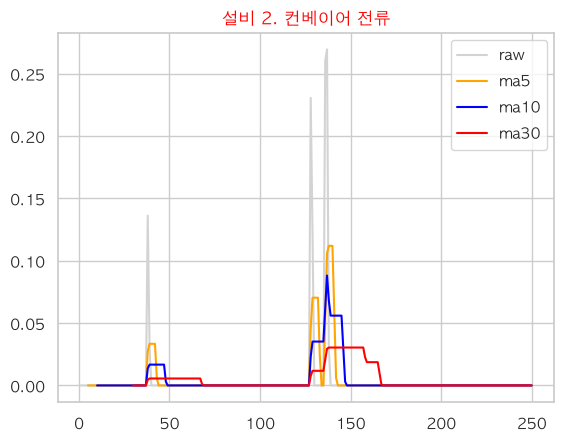

In [23]:
# 실습 3 코드

unit2["ma10"] = unit2["컨베이어전류"].rolling(window=10).mean()
unit2["ma5"] = unit2["컨베이어전류"].rolling(window=5).mean()
unit2["ma30"] = unit2["컨베이어전류"].rolling(window=30).mean()

unit2.tail(10)

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color="lightgray", label="raw")
plt.plot(unit2["시퀀스"], unit2["ma5"], color="orange", label="ma5")  # 조금 더 평탄화됨
plt.plot(unit2["시퀀스"], unit2["ma10"], color="blue", label="ma10")
plt.plot(unit2["시퀀스"], unit2["ma30"], color="red", label="ma30") 


# window가 클수록 더욱 평탄화 됨 
plt.legend()
plt.title("설비 2. 컨베이어 전류", color="red")
plt.show()

## 실습 4. 이동평균·이동표준편차 동시 추적
### 목표
이동평균과 이동표준편차를 함께 계산해 추세와 변동성을 동시에 추적
### 단계
- 창 크기 10으로 이동평균과 이동표준편차를 구하기
- 두 통계를 위아래 두 칸으로 나눠 그리기
- 초반과 후반의 변동성 평균을 비교
### 예상 결과
후반 변동성이 초반의 약 2배(5.5 → 9.5)로 커짐

In [24]:
# 실습 4 코드

unit2["st10"] = unit2["컨베이어전류"].rolling(window=10).std()

early = unit2["st10"].iloc[10:50].mean()
late = unit2["st10"].iloc[150:].mean()

print(f"초반 변동성 : {round(early,4)}")
print(f"후반 변동성 : {round(late,4)}")

초반 변동성 : 0.011
후반 변동성 : 0.0


## 실습 5. 변화량·변화율 계산과 시각화
### 목표
변화량과 변화율로 급변을 포착하고 이동평균 후 변화량으로 잡음을 줄이기
### 단계
- 직전 대비 변화량과 변화율을 각각 구하기
- 앞부분 값을 확인해 첫 값이 비는 이유 이해
- 이동평균을 먼저 낸 뒤 변화량을 구해 잡음이 줄어듦을 확인
### 예상 결과
변화량 앞부분 -0.43·3.07…, 첫 값은 비교 대상이 없어 빈 값

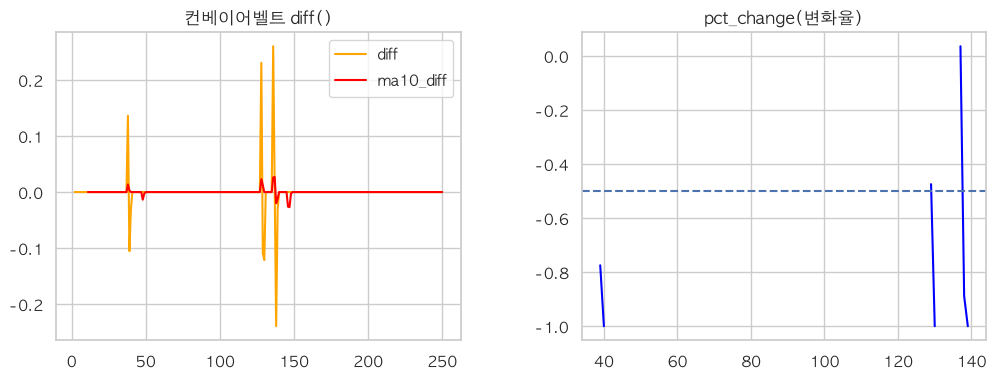

In [25]:
# 실습 5 코드

unit2["diff"] = unit2["컨베이어전류"].diff()
unit2["pct"] = unit2["컨베이어전류"].pct_change()
unit2["ma10_diff"] = unit2["ma10"].diff()

unit2.tail(20)

# 위 항목들을 그래프로
plt.figure(figsize=(12, 4))
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # 간격조정


plt.subplot(1,2,1)

plt.plot(unit2["시퀀스"], unit2["diff"], color="orange", label="diff")  # 조금 더 평탄화됨
plt.plot(unit2["시퀀스"], unit2["ma10_diff"], color="red", label="ma10_diff")
plt.title("컨베이어벨트 diff()")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(unit2["시퀀스"],unit2["pct"], color="blue", label="pct")
plt.axhline(-0.5, linestyle="--")
plt.title("pct_change(변화율)")

plt.show()

## 실습 6. 단순 변화점 탐지와 구간 표시
### 목표
잔차와 임계값으로 변화점을 찾고 그래프에 세로선으로 표시
### 단계
- 원본에서 이동평균을 뺀 잔차를 구하기
- 잔차 표준편차의 두 배를 임계값으로 정해 변화점 표시
- 변화점 위치를 세로선으로 그래프에 표시
### 예상 결과
임계값 약 16.3, 변화점 13개; 대부분 후반부에 몰림

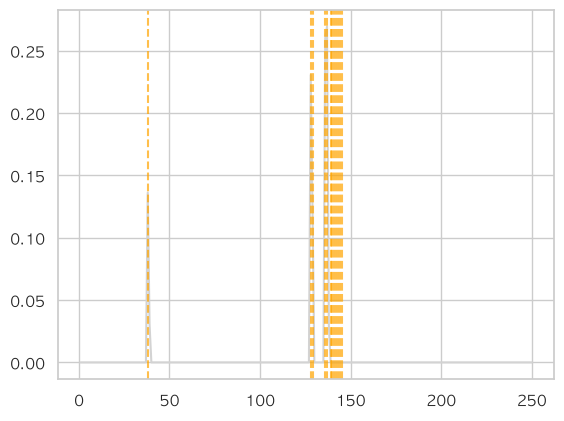

In [26]:
# 실습 6 코드

roli = unit2["컨베이어전류"].rolling(10).mean()
resid = unit2["컨베이어전류"] - roli

# 잔차 표준편차의 두배를 임계값으로 정함 
thr = 2 * resid.std()

# 변화점찾기 
unit2["is_change"] = resid.abs() > thr 

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color="lightgray")

for c in unit2.loc[unit2["is_change"], "시퀀스"]:
    plt.axvline(c, color="orange", linestyle = '--', alpha=0.7)

plt.show()

## 실습 7. window·기준값 바꿔 결과 비교
### 목표
창 크기와 임계 배수를 바꿔 변화점 개수가 어떻게 달라지는지 비교
### 단계
· 잔차 기반 변화점 개수를 세는 함수를 만들기
· 창 크기를 바꿔 가며 변화점 개수 비교
· 임계 배수를 바꿔 가며 변화점 개수 비교
### 예상 결과
창이 커지거나 배수가 작아질수록 변화점 개수가 달라짐

In [27]:
# 실습 7 코드

series = unit2["컨베이어전류"]

k =2 

for window in [5,10,20] :
    r = series - series.rolling(window).mean()
    print("window :", window, int((r.abs() > k * r.std()).sum()))


window = 10 

for k in [1.5, 2.0, 3.0] :
    r = series - series.rolling(window).mean()
    print("k :", k, int((r.abs() > k*r.std()).sum()))

window : 5 11
window : 10 12
window : 20 5
k : 1.5 12
k : 2.0 12
k : 3.0 5


## 실습 8. 단일 설비 상태 추적 미니 통합
### 목표
이동통계·변화점·변동성을 한데 모아 한 엔진의 상태를 요약
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 후반 변화점 비율로 상태를 한 문장으로 진단
### 예상 결과
후반 변동성이 커지고 변화점 13개, 후반 비율이 높아 열화 진행

In [30]:
# 실습 8 코드

series = unit2["컨베이어전류"]
window = 10

unit2["ma"] = series.rolling(window).mean() # 이동평균
unit2["std"] = series.rolling(window).std() # 이동표준편차

resid = series - unit2["ma"]
thr = 2 * resid.std() # 잔차 표준편차의 두배를 임계값으로 정함

unit2["chg"] = resid.abs() > thr # 변화점을 찾기 
half = unit2["시퀀스"].median()

print("전반부 변동성")
print("이동표준편차 :", round(unit2["std"].iloc[10:50].mean(), 4))
print("후반부 변동성")
print("이동표준편차 :", round(unit2["std"].iloc[150:].mean(), 4))

print("-"*30)
print("변화점 : ", int(unit2["chg"].sum()))
print("후반 비율 : ", round(unit2.loc[unit2["시퀀스"]>half, "chg"].mean(),2))

전반부 변동성
이동표준편차 : 0.011
후반부 변동성
이동표준편차 : 0.0
------------------------------
변화점 :  12
후반 비율 :  0.09
